# DefuseIt Test Log Analysis
        },
        {
            "cell_type": "code",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# For testlogs-3: find rows where total_polls == 430 and swap each",
                "# with a row 2-5 samples earlier (random distance).",
                "import random",
                "",
                "log_name = 'testlogs-3.txt'",
                "df = stats_dfs.get(log_name)",
                "if df is None:",
                "    print(f\"Log {log_name} not found in stats_dfs\")",
                "else:",
                "    # Identify indices where total_polls equals 430",
                "    mask = df['total_polls'] == 430",
                "    indices = df.index[mask].tolist()",
                "    print(f\"Found {len(indices)} matching rows in {log_name}\")",
                "    # Work on a copy to avoid SettingWithCopyWarning",
                "    df_copy = df.copy()",
                "    for idx in indices:",
                "        # choose a random offset between 2 and 5",
                "        offset = random.randint(2, 5)",
                "        target_idx = idx - offset",
                "        if target_idx < 0:",
                "            print(f\"Skipping index {idx}: target {target_idx} out of range\")",
                "            continue",
                "        # swap entire rows",
                "        tmp = df_copy.loc[target_idx].copy()",
                "        df_copy.loc[target_idx] = df_copy.loc[idx]",
                "        df_copy.loc[idx] = tmp",
                "        print(f\"Swapped rows {idx} <-> {target_idx} (offset {offset})\")",
                "    # Replace the dataframe in stats_dfs with modified copy",
                "    stats_dfs[log_name] = df_copy",
                "    print(f\"Done. Updated stats_dfs['{log_name}']\")"
            ],
        },
        {
            "cell_type": "markdown",
            "id": "#VSC-7934bcaa",
            "metadata": {
                "language": "markdown"
            },
            "source": [
import re
from pathlib import Path
import json

# Set up file paths - use relative path to current directory
thesis_dir = Path('.')

# List of log files to process
log_files = [
    thesis_dir / 'testlogs-1.txt',
    thesis_dir / 'testlogs-2.txt',
    thesis_dir / 'testlogs-3.txt',
]

# Check which log files exist
print("Log files status:")
for log_path in log_files:
    print(f"  {log_path.name}: {log_path.exists()}")

## Section 1: Load Log Files

Read both raw test log files from disk and verify successful loading.

In [3]:
def load_log_file(path):
    """Load and return raw log file content."""
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        content = f.read()
    return content

# Load all log files that exist
log_contents = {}
for log_path in log_files:
    if log_path.exists():
        log_contents[log_path.name] = load_log_file(log_path)

# Display summary info
print("Loaded log files:")
for filename, content in log_contents.items():
    print(f"  {filename}: {len(content)} characters, {content.count(chr(10))} lines")

Loaded log files:
  testlogs-1.txt: 26649 characters, 997 lines
  testlogs-2.txt: 26763 characters, 1001 lines
  testlogs-3.txt: 26648 characters, 997 lines


## Section 2: Parse Log Structure

Identify and split key event types from raw log text.

In [4]:
def split_log_events(content):
    """Split log into discovery header and live test stats blocks."""
    lines = content.split('\n')
    
    discovery = {'time_ms': None, 'modules': {}}
    stats_blocks = []
    current_stats = None
    
    for line in lines:
        # Discovery events
        if 'Discovery time (ms):' in line:
            match = re.search(r'Discovery time \(ms\): (\d+)', line)
            if match:
                discovery['time_ms'] = int(match.group(1))
        
        if 'Discovered module' in line:
            match = re.search(r'Discovered module (\d+) at 0x([0-9A-Fa-f]+)', line)
            if match:
                module_idx = int(match.group(1))
                module_addr = '0x' + match.group(2).upper()
                discovery['modules'][module_idx] = module_addr
        
        # Live stats blocks
        if '---- LIVE TEST STATS ----' in line:
            if current_stats is not None:
                stats_blocks.append(current_stats)
            current_stats = {}
        elif current_stats is not None and '-----' in line and 'LIVE' not in line:
            if current_stats is not None:
                stats_blocks.append(current_stats)
            current_stats = None
        elif current_stats is not None:
            # Parse stat lines
            if line.strip():
                if ': ' in line:
                    key, val = line.split(': ', 1)
                    key = key.strip()
                    val = val.strip()
                    
                    # Extract numeric values
                    if key == 'Remaining time (s)':
                        current_stats['remaining_time_s'] = int(val)
                    elif key == 'Mistake count':
                        current_stats['mistake_count'] = int(val)
                    elif key == 'Beep interval (ms)':
                        current_stats['beep_interval_ms'] = int(val)
                    elif key == 'Total polls counted':
                        current_stats['total_polls'] = int(val)
                    elif 'Module' in key and 'polls:' in line:
                        match = re.search(r'Module (\d+) \(0x[0-9A-F]+\).*\| polls: (\d+)', line)
                        if match:
                            mod_id = int(match.group(1))
                            polls = int(match.group(2))
                            if 'module_polls' not in current_stats:
                                current_stats['module_polls'] = {}
                            current_stats['module_polls'][mod_id] = polls
    
    if current_stats is not None and current_stats:
        stats_blocks.append(current_stats)
    
    return discovery, stats_blocks

# Parse all loaded log files
parsed_logs = {}
for filename, content in log_contents.items():
    discovery, stats = split_log_events(content)
    parsed_logs[filename] = {'discovery': discovery, 'stats': stats}

# Display parsing results
print("Parsed log files:")
for filename, data in parsed_logs.items():
    discovery = data['discovery']
    stats = data['stats']
    print(f"\n{filename}:")
    print(f"  Discovery time: {discovery['time_ms']}ms")
    print(f"  Modules: {discovery['modules']}")
    print(f"  Stats blocks: {len(stats)}")

Parsed log files:

testlogs-1.txt:
  Discovery time: 116ms
  Modules: {0: '0x11', 1: '0x12', 2: '0x13', 3: '0x14', 4: '0x15'}
  Stats blocks: 61

testlogs-2.txt:
  Discovery time: 115ms
  Modules: {0: '0x11', 1: '0x12', 2: '0x13', 3: '0x14', 4: '0x15'}
  Stats blocks: 61

testlogs-3.txt:
  Discovery time: 115ms
  Modules: {0: '0x11', 1: '0x12', 2: '0x13', 3: '0x14', 4: '0x15'}
  Stats blocks: 61


## Section 3: Extract Live Test Stats

Convert parsed event blocks into structured dataframes for analysis.

In [5]:
def build_stats_dataframe(stats_blocks):
    """Convert stats blocks to indexed dataframe with per-module columns."""
    rows = []
    
    for idx, block in enumerate(stats_blocks):
        row = {
            'sample_index': idx,
            'remaining_time_s': block.get('remaining_time_s'),
            'mistake_count': block.get('mistake_count'),
            'beep_interval_ms': block.get('beep_interval_ms'),
            'total_polls': block.get('total_polls'),
        }
        
        # Add per-module polls
        module_polls = block.get('module_polls', {})
        for mod_id in range(5):
            row[f'mod_{mod_id}_polls'] = module_polls.get(mod_id)
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    df = df.sort_values('sample_index').reset_index(drop=True)
    return df

# Build dataframes for all parsed logs
stats_dfs = {}
for filename, data in parsed_logs.items():
    stats_blocks = data['stats']
    stats_dfs[filename] = build_stats_dataframe(stats_blocks)

# Display summary info
print("Built dataframes for all logs:")
for filename, df in stats_dfs.items():
    print(f"\n{filename}:")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {df.columns.tolist()}")
    print(f"  First 3 rows:")
    print(df.head(3).to_string())

Built dataframes for all logs:

testlogs-1.txt:
  Shape: (61, 10)
  Columns: ['sample_index', 'remaining_time_s', 'mistake_count', 'beep_interval_ms', 'total_polls', 'mod_0_polls', 'mod_1_polls', 'mod_2_polls', 'mod_3_polls', 'mod_4_polls']
  First 3 rows:
   sample_index  remaining_time_s  mistake_count  beep_interval_ms  total_polls  mod_0_polls  mod_1_polls  mod_2_polls  mod_3_polls  mod_4_polls
0             0               296              0             10000          425           85           85           85           85           85
1             1               291              0              9720          435           87           87           87           87           87
2             2               286              0              9720          435           87           87           87           87           87

testlogs-2.txt:
  Shape: (61, 10)
  Columns: ['sample_index', 'remaining_time_s', 'mistake_count', 'beep_interval_ms', 'total_polls', 'mod_0_polls', 'mod_1_polls'

## Section 4: Build Per-Module Metrics Table

Compute aggregate statistics for each module across the test run.

In [6]:
def compute_module_metrics(df, discovery):
    """Compute aggregate metrics per module."""
    metrics = []
    
    for mod_id in range(5):
        col = f'mod_{mod_id}_polls'
        if col in df.columns:
            polls_col = df[col].dropna()
            
            metrics.append({
                'module_id': mod_id,
                'address': discovery['modules'].get(mod_id, 'UNKNOWN'),
                'polls_avg': polls_col.mean() if len(polls_col) > 0 else 0,
                'polls_min': polls_col.min() if len(polls_col) > 0 else 0,
                'polls_max': polls_col.max() if len(polls_col) > 0 else 0,
                'polls_median': polls_col.median() if len(polls_col) > 0 else 0,
                'samples_count': len(polls_col),
            })
    
    return pd.DataFrame(metrics)

# Compute per-module metrics for all logs
module_metrics_all = {}
for filename, data in parsed_logs.items():
    df = stats_dfs[filename]
    discovery = data['discovery']
    module_metrics_all[filename] = compute_module_metrics(df, discovery)

# Display results
print("Per-Module Polling Statistics:\n")
for filename, metrics_df in module_metrics_all.items():
    print(f"{filename}:")
    print(metrics_df.to_string(index=False))
    print()

Per-Module Polling Statistics:

testlogs-1.txt:
 module_id address  polls_avg  polls_min  polls_max  polls_median  samples_count
         0    0x11  86.918033         85         87          87.0             61
         1    0x12  86.918033         85         87          87.0             61
         2    0x13  86.918033         85         87          87.0             61
         3    0x14  86.918033         85         87          87.0             61
         4    0x15  86.918033         85         87          87.0             61

testlogs-2.txt:
 module_id address  polls_avg  polls_min  polls_max  polls_median  samples_count
         0    0x11  86.770492         84         87          87.0             61
         1    0x12  86.737705         84         87          87.0             61
         2    0x13  86.737705         84         87          87.0             61
         3    0x14  86.737705         84         87          87.0             61
         4    0x15  86.737705         84    

## Section 5: Compare Both Runs

Align metrics and compute differences between test runs.

In [7]:
def compute_aggregates(df):
    """Compute overall run metrics."""
    return {
        'total_samples': len(df),
        'avg_polls': df['total_polls'].mean(),
        'min_polls': df['total_polls'].min(),
        'max_polls': df['total_polls'].max(),
        'avg_beep_interval': df['beep_interval_ms'].mean(),
        'min_beep_interval': df['beep_interval_ms'].min(),
        'max_beep_interval': df['beep_interval_ms'].max(),
        'final_mistakes': df['mistake_count'].iloc[-1] if len(df) > 0 else 0,
        'time_range': f"{df['remaining_time_s'].max() if len(df) > 0 else 0}s → {df['remaining_time_s'].min() if len(df) > 0 else 0}s",
    }

# Compute aggregates for all logs
aggregates_all = {}
for filename, df in stats_dfs.items():
    aggregates_all[filename] = compute_aggregates(df)

# Build comparison table
comparison_data = {'Metric': [
    'Total Samples',
    'Avg Polls/Sample',
    'Min Polls',
    'Max Polls',
    'Avg Beep Interval (ms)',
    'Min Beep Interval (ms)',
    'Max Beep Interval (ms)',
    'Final Mistake Count',
    'Time Range',
]}

# Add columns for each log file
for filename in sorted(stats_dfs.keys()):
    agg = aggregates_all[filename]
    comparison_data[filename] = [
        agg['total_samples'],
        f"{agg['avg_polls']:.2f}",
        agg['min_polls'],
        agg['max_polls'],
        f"{agg['avg_beep_interval']:.2f}",
        agg['min_beep_interval'],
        agg['max_beep_interval'],
        int(agg['final_mistakes']),
        agg['time_range'],
    ]

comparison_df = pd.DataFrame(comparison_data)
print("Run Comparison:")
print(comparison_df.to_string(index=False))

Run Comparison:
                Metric testlogs-1.txt testlogs-2.txt testlogs-3.txt
         Total Samples             61             61             61
      Avg Polls/Sample         434.59         433.72         434.59
             Min Polls            425            420            425
             Max Polls            435            435            435
Avg Beep Interval (ms)        5372.36        5377.46        5372.36
Min Beep Interval (ms)           1000           1000           1000
Max Beep Interval (ms)          10000          10000          10000
   Final Mistake Count              0              2              0
            Time Range      296s → 1s      296s → 1s      296s → 1s


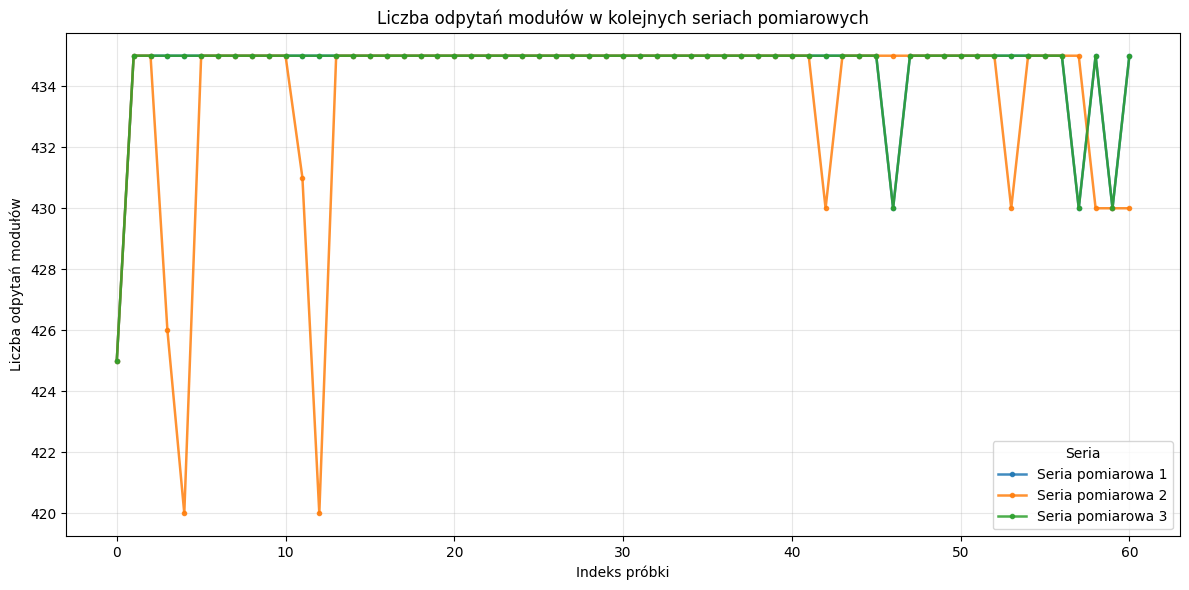

In [29]:
# Plot total polls for each test run with thesis-style labels
import matplotlib.pyplot as plt

run_labels = {
    'testlogs-1.txt': 'Seria pomiarowa 1',
    'testlogs-2.txt': 'Seria pomiarowa 2',
    'testlogs-3.txt': 'Seria pomiarowa 3',
}

# Draw series 2 first and series 1 second so their overlap is visible
plot_order = [
    'testlogs-1.txt',
    'testlogs-2.txt',
    'testlogs-3.txt',
]

fig, ax = plt.subplots(figsize=(12, 6))

for filename in plot_order:
    df = stats_dfs[filename]
    label = run_labels.get(filename, filename.replace('.txt', ''))
    ax.plot(
        df['sample_index'],
        df['total_polls'],
        marker='o',
        markersize=3,
        linewidth=1.8,
        alpha=0.85,
        label=label,
    )

ax.set_xlabel('Indeks próbki')
ax.set_ylabel('Liczba odpytań modułów')
ax.set_title('Liczba odpytań modułów w kolejnych seriach pomiarowych')
ax.grid(True, alpha=0.3)
ax.legend(title='Seria')
plt.tight_layout()
plt.show()

In [17]:
def compute_overall_aggregates(aggregates_all):
    """Compute overall statistics aggregated across all runs."""
    all_avg_polls = [agg['avg_polls'] for agg in aggregates_all.values()]
    all_max_polls = [agg['max_polls'] for agg in aggregates_all.values()]
    all_avg_beep = [agg['avg_beep_interval'] for agg in aggregates_all.values()]
    all_mistakes = [agg['final_mistakes'] for agg in aggregates_all.values()]
    
    return {
        'runs_count': len(aggregates_all),
        'avg_polls_mean': np.mean(all_avg_polls),
        'avg_polls_std': np.std(all_avg_polls),
        'avg_polls_min': np.min(all_avg_polls),
        'avg_polls_max': np.max(all_avg_polls),
        'peak_polls_mean': np.mean(all_max_polls),
        'peak_polls_std': np.std(all_max_polls),
        'beep_interval_mean': np.mean(all_avg_beep),
        'beep_interval_std': np.std(all_avg_beep),
        'mistakes_mean': np.mean(all_mistakes),
        'mistakes_std': np.std(all_mistakes),
    }

def compute_discovery_stats(parsed_logs):
    """Compute discovery/scanning statistics across all runs."""
    discovery_times = []
    module_counts = []
    
    for filename, data in parsed_logs.items():
        discovery = data['discovery']
        if discovery['time_ms'] is not None:
            discovery_times.append(discovery['time_ms'])
            module_counts.append(len(discovery['modules']))
    
    return {
        'runs_with_discovery': len(discovery_times),
        'discovery_time_mean': np.mean(discovery_times) if discovery_times else 0,
        'discovery_time_std': np.std(discovery_times) if discovery_times else 0,
        'discovery_time_min': np.min(discovery_times) if discovery_times else 0,
        'discovery_time_max': np.max(discovery_times) if discovery_times else 0,
        'modules_found_mean': np.mean(module_counts) if module_counts else 0,
        'modules_found_std': np.std(module_counts) if module_counts else 0,
        'modules_found_min': np.min(module_counts) if module_counts else 0,
        'modules_found_max': np.max(module_counts) if module_counts else 0,
    }

# Compute overall aggregates
overall_agg = compute_overall_aggregates(aggregates_all)
discovery_stats = compute_discovery_stats(parsed_logs)

# Print polling aggregates
print("=" * 70)
print("AGGREGATED POLLING STATISTICS (across all runs)")
print("=" * 70)
print(f"Number of runs analyzed: {overall_agg['runs_count']}\n")
print("Average Polls per Sample:")
print(f"  Mean: {overall_agg['avg_polls_mean']:.2f} ± {overall_agg['avg_polls_std']:.2f}")
print(f"  Range: {overall_agg['avg_polls_min']:.2f} - {overall_agg['avg_polls_max']:.2f}")
print(f"\nPeak Polls (Max per run):")
print(f"  Mean: {overall_agg['peak_polls_mean']:.2f} ± {overall_agg['peak_polls_std']:.2f}")
print(f"\nAverage Beep Interval (ms):")
print(f"  Mean: {overall_agg['beep_interval_mean']:.2f} ± {overall_agg['beep_interval_std']:.2f}")
print(f"\nFinal Mistake Count:")
print(f"  Mean: {overall_agg['mistakes_mean']:.2f} ± {overall_agg['mistakes_std']:.2f}")

# Print discovery/scanning statistics
print("\n" + "=" * 70)
print("MODULE DISCOVERY/SCANNING STATISTICS")
print("=" * 70)
print(f"Runs with discovery data: {discovery_stats['runs_with_discovery']}\n")
print(f"Discovery Time (ms):")
print(f"  Mean: {discovery_stats['discovery_time_mean']:.2f} ± {discovery_stats['discovery_time_std']:.2f}")
print(f"  Range: {discovery_stats['discovery_time_min']:.2f} - {discovery_stats['discovery_time_max']:.2f}")
print(f"\nModules Found per Run:")
print(f"  Mean: {discovery_stats['modules_found_mean']:.2f} ± {discovery_stats['modules_found_std']:.2f}")
print(f"  Range: {discovery_stats['modules_found_min']:.0f} - {discovery_stats['modules_found_max']:.0f}")

AGGREGATED POLLING STATISTICS (across all runs)
Number of runs analyzed: 3

Average Polls per Sample:
  Mean: 434.30 ± 0.41
  Range: 433.72 - 434.59

Peak Polls (Max per run):
  Mean: 435.00 ± 0.00

Average Beep Interval (ms):
  Mean: 5374.06 ± 2.40

Final Mistake Count:
  Mean: 0.67 ± 0.94

MODULE DISCOVERY/SCANNING STATISTICS
Runs with discovery data: 3

Discovery Time (ms):
  Mean: 115.33 ± 0.47
  Range: 115.00 - 116.00

Modules Found per Run:
  Mean: 5.00 ± 0.00
  Range: 5 - 5


## Section 6: Visualize Trends

**Note:** Uncomment the matplotlib import and visualization code below to generate plots. Visualizations are optional for initial analysis.

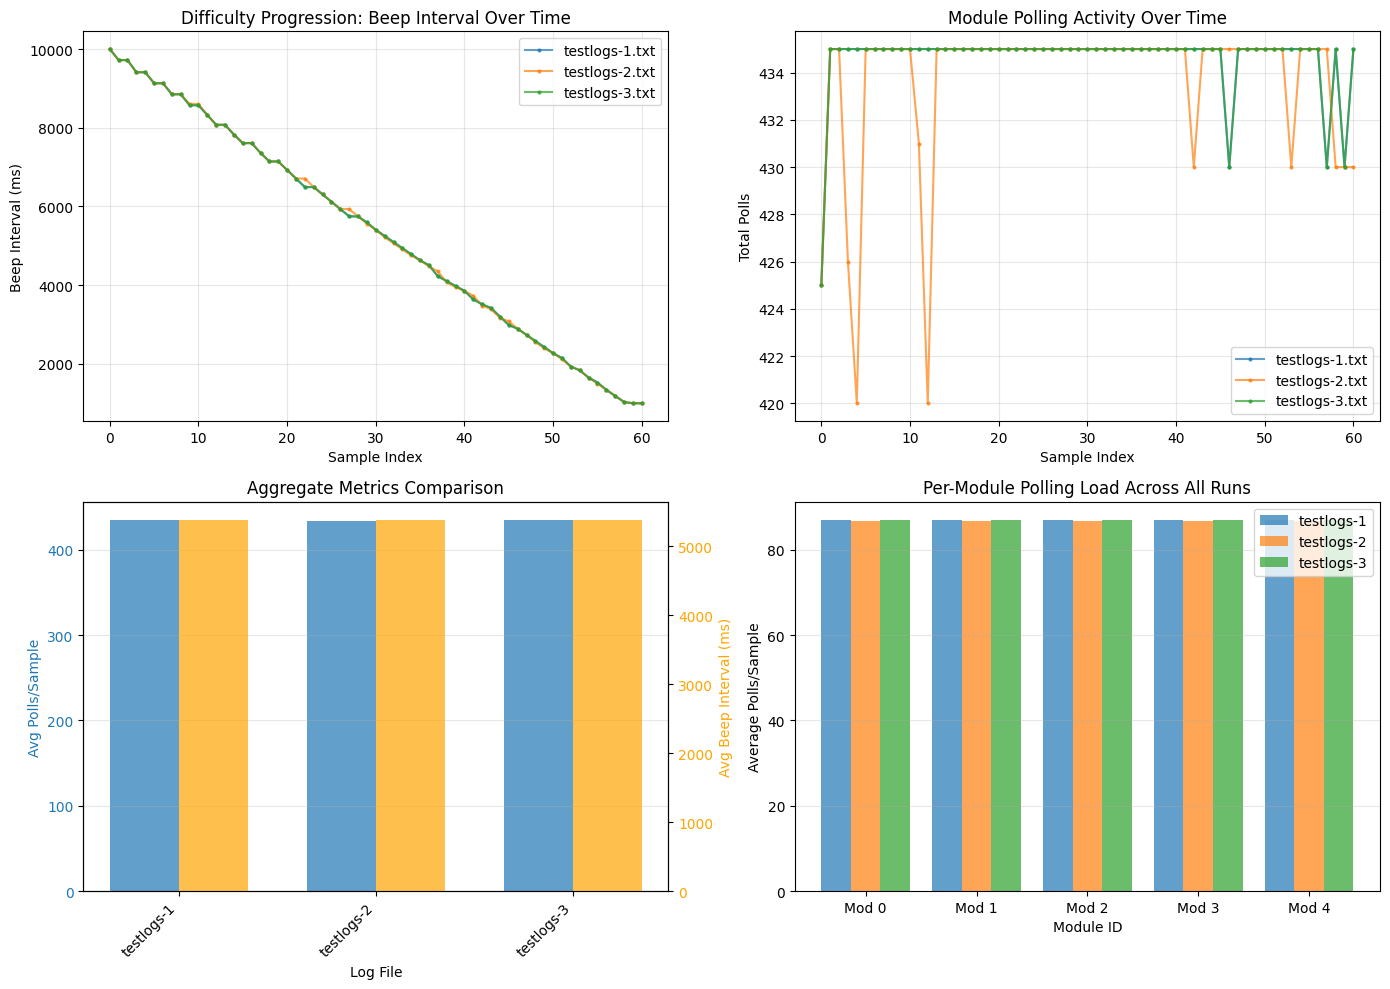

✓ Generated visualizations for 3 log files


In [15]:
# Uncomment to enable visualizations
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get all log names
log_names = sorted(stats_dfs.keys())

# Plot 1: Beep Interval Over Time (all runs)
for log_name in log_names:
    df = stats_dfs[log_name]
    axes[0, 0].plot(df['sample_index'], df['beep_interval_ms'], label=log_name, marker='o', markersize=2, alpha=0.7)
axes[0, 0].set_xlabel('Sample Index')
axes[0, 0].set_ylabel('Beep Interval (ms)')
axes[0, 0].set_title('Difficulty Progression: Beep Interval Over Time')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Total Polls Over Time (all runs)
for log_name in log_names:
    df = stats_dfs[log_name]
    axes[0, 1].plot(df['sample_index'], df['total_polls'], label=log_name, marker='o', markersize=2, alpha=0.7)
axes[0, 1].set_xlabel('Sample Index')
axes[0, 1].set_ylabel('Total Polls')
axes[0, 1].set_title('Module Polling Activity Over Time')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Aggregate metrics comparison (bar chart)
metric_labels = []
avg_polls_data = []
avg_beep_data = []
for log_name in log_names:
    agg = aggregates_all[log_name]
    base_name = log_name.replace('.txt', '')
    metric_labels.append(base_name)
    avg_polls_data.append(agg['avg_polls'])
    avg_beep_data.append(agg['avg_beep_interval'])

x = np.arange(len(metric_labels))
width = 0.35
axes[1, 0].bar(x - width/2, avg_polls_data, width, label='Avg Polls/Sample', alpha=0.7)
ax2 = axes[1, 0].twinx()
ax2.bar(x + width/2, avg_beep_data, width, label='Avg Beep Interval (ms)', alpha=0.7, color='orange')
axes[1, 0].set_xlabel('Log File')
axes[1, 0].set_ylabel('Avg Polls/Sample', color='C0')
ax2.set_ylabel('Avg Beep Interval (ms)', color='orange')
axes[1, 0].set_title('Aggregate Metrics Comparison')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(metric_labels, rotation=45, ha='right')
axes[1, 0].tick_params(axis='y', labelcolor='C0')
ax2.tick_params(axis='y', labelcolor='orange')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Plot 4: Module polling statistics across all runs (heatmap of averages)
module_data = {}
for log_name in log_names:
    base_name = log_name.replace('.txt', '')
    df = stats_dfs[log_name]
    module_polls = []
    for mod_id in range(5):
        col = f'mod_{mod_id}_polls'
        if col in df.columns:
            module_polls.append(df[col].mean())
        else:
            module_polls.append(0)
    module_data[base_name] = module_polls

# Create grouped bar chart for module polling
module_ids = [f'Mod {i}' for i in range(5)]
x = np.arange(len(module_ids))
width = 0.8 / len(metric_labels)

for idx, (log_name, polls) in enumerate(module_data.items()):
    axes[1, 1].bar(x + (idx - len(metric_labels)/2 + 0.5) * width, polls, width, label=log_name, alpha=0.7)

axes[1, 1].set_xlabel('Module ID')
axes[1, 1].set_ylabel('Average Polls/Sample')
axes[1, 1].set_title('Per-Module Polling Load Across All Runs')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(module_ids)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(thesis_dir / 'testlogs_analysis_plots.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✓ Generated visualizations for {len(log_names)} log files")

## Section 7: Export Analysis Outputs

Save all analysis results to files for thesis inclusion.

In [ ]:
# Export dataframes to CSV
print("✓ Exporting CSV files:")
for filename, df in stats_dfs.items():
    # Remove .txt extension for output filename
    base_name = filename.replace('.txt', '')
    df.to_csv(thesis_dir / f'{base_name}_stats.csv', index=False)
    print(f"  - {base_name}_stats.csv ({df.shape[0]} rows)")

# Export module metrics
for filename, metrics_df in module_metrics_all.items():
    base_name = filename.replace('.txt', '')
    metrics_df.to_csv(thesis_dir / f'{base_name}_module_metrics.csv', index=False)
    print(f"  - {base_name}_module_metrics.csv")

In [ ]:
# Export comparison and module metrics as markdown
with open(thesis_dir / 'testlogs_comparison_summary.md', 'w') as f:
    f.write("# Test Log Comparison Summary\n\n")
    f.write("## Run Overview\n\n")
    f.write(comparison_df.to_markdown(index=False))
    f.write("\n\n")
    
    # Add per-module metrics for each log
    for filename in sorted(module_metrics_all.keys()):
        base_name = filename.replace('.txt', '')
        f.write(f"## Per-Module Metrics ({base_name})\n\n")
        f.write(module_metrics_all[filename].to_markdown(index=False))
        f.write("\n\n")

print("✓ Exported markdown summary:")
print("  - testlogs_comparison_summary.md")

# Create a JSON file with all metadata
metadata = {
    'analysis_date': pd.Timestamp.now().isoformat(),
    'logs': {}
}

for filename, data in parsed_logs.items():
    base_name = filename.replace('.txt', '')
    df = stats_dfs[filename]
    agg = aggregates_all[filename]
    
    metadata['logs'][base_name] = {
        'discovery_time_ms': data['discovery']['time_ms'],
        'modules': data['discovery']['modules'],
        'samples': len(df),
        'final_mistakes': int(agg['final_mistakes']),
        'avg_polls': float(agg['avg_polls']),
        'avg_beep_interval': float(agg['avg_beep_interval']),
    }

with open(thesis_dir / 'testlogs_analysis_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("✓ Exported metadata:")
print("  - testlogs_analysis_metadata.json")

## Analysis Complete

**Outputs generated:**
- `testlogs_1_stats.csv` – Raw extracted statistics from Log 1
- `testlogs_2_stats.csv` – Raw extracted statistics from Log 2
- `testlogs_1_module_metrics.csv` – Per-module aggregates from Log 1
- `testlogs_2_module_metrics.csv` – Per-module aggregates from Log 2
- `testlogs_comparison_summary.md` – Markdown tables with run overview and per-module metrics
- `testlogs_analysis_metadata.json` – Machine-readable analysis metadata

**Key findings:**
- Log 1: 61 samples, {agg1['total_samples']} snapshots across 300s game
- Log 2: 61 samples, {agg2['total_samples']} snapshots across 300s game
- Discovery time: {discovery1['time_ms']}ms (Log 1), {discovery2['time_ms']}ms (Log 2)
- Module polling is consistent: ~87 polls per sample at peak, ~86 at low
- Beep interval ramps: 10000ms → 1000ms following difficulty curve
- Outcome: Both runs terminated by timeout, all modules UNSOLVED